In [1]:
from datetime import datetime

In [2]:
import arcgis
from arcgis.gis import GIS

gis = GIS("https://pythonapi.playground.esri.com/portal", "arcgis_python", "amazing_arcgis_123")
gis

GIS @ https://pythonapi.playground.esri.com/portal version:7.1

In [3]:
arcgis.env.verbose=True

In [4]:
degs=gis.content.search("title: degs")[0].layers[0]
degs.url

'https://pythonapi.playground.esri.com/server/rest/services/degs/ImageServer'

In [5]:
negs=gis.content.search("title: negs")[0].layers[0]
negs.url

'https://pythonapi.playground.esri.com/server/rest/services/negs/ImageServer'

In [6]:
multi_srw = gis.content.search("multi_srw")[0].layers[0]
multi_srw.url

'https://pythonapi.playground.esri.com/server/rest/services/multi_srw/ImageServer'

In [7]:
multi_sae = gis.content.search("multi_sae")[0].layers[0]
multi_sae.url

'https://pythonapi.playground.esri.com/server/rest/services/multi_sae/ImageServer'

Summarize Raster Within with default values

Submitted.
Executing...
SummarizeRasterWithin GP Job: ja571d07b5b5e486e8aa243d4b90a7d1a finished successfully.


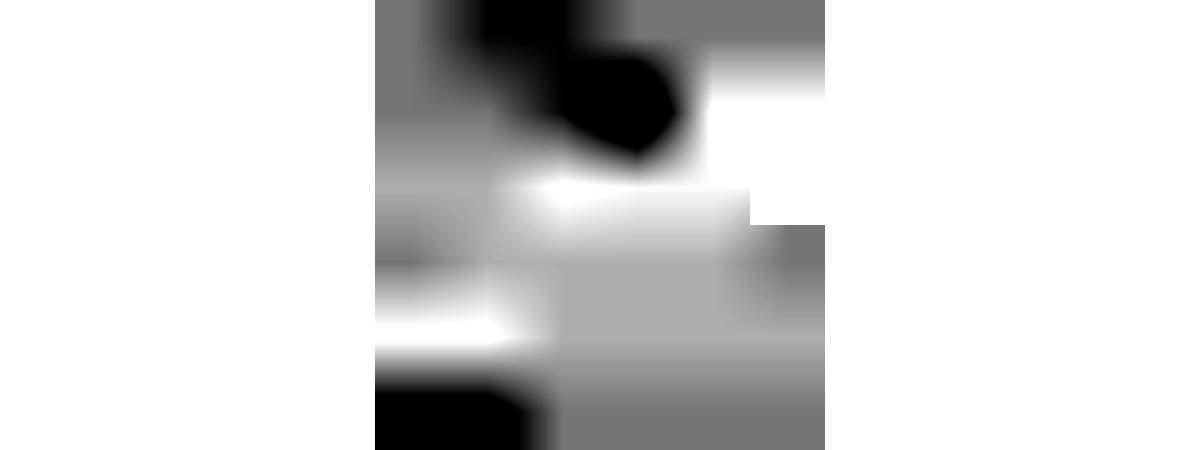

In [8]:
summarize_raster_within_1 = arcgis.raster.analytics.summarize_raster_within(input_zone_layer=degs,
                                                                            input_raster_layer_to_summarize=negs,
                                                                            zone_field="VALUE",
                                                                            ignore_missing_values=True,
                                                                            output_name="summarize_raster_within_" + str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                                            gis=gis)
summarize_raster_within_1.layers[0]

Summarize Raster Within with statistic_type MAJORITY and context value set

In [9]:
aoi = {"xmin": 0,"ymin": 1, "xmax": 5,"ymax": 4,"spatialReference": {"wkid": None}}

Submitted.
Executing...
SummarizeRasterWithin GP Job: j531ead08d3dc45889ca9c26776bcac3a finished successfully.


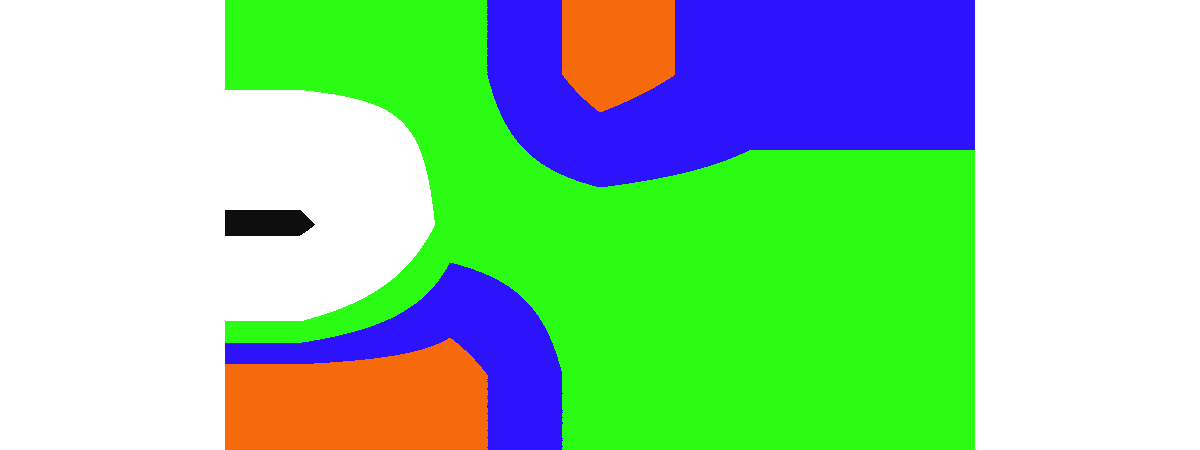

In [10]:
summarize_raster_within_2 = arcgis.raster.analytics.summarize_raster_within(input_zone_layer=degs,
                                                                            input_raster_layer_to_summarize=negs,
                                                                            zone_field="VALUE",
                                                                            ignore_missing_values=True,
                                                                            statistic_type="MAJORITY",
                                                                            output_name="summarize_raster_within_" + str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                                            context={"extent":aoi},
                                                                            future=True,
                                                                            gis=gis)


summarize_raster_within_2.result().layers[0]

Summarize Raster Within with environment varable analysis_extent set

Submitted.
Executing...
SummarizeRasterWithin GP Job: j60a43305632b46eb9fc7ae6fac1a57e5 finished successfully.


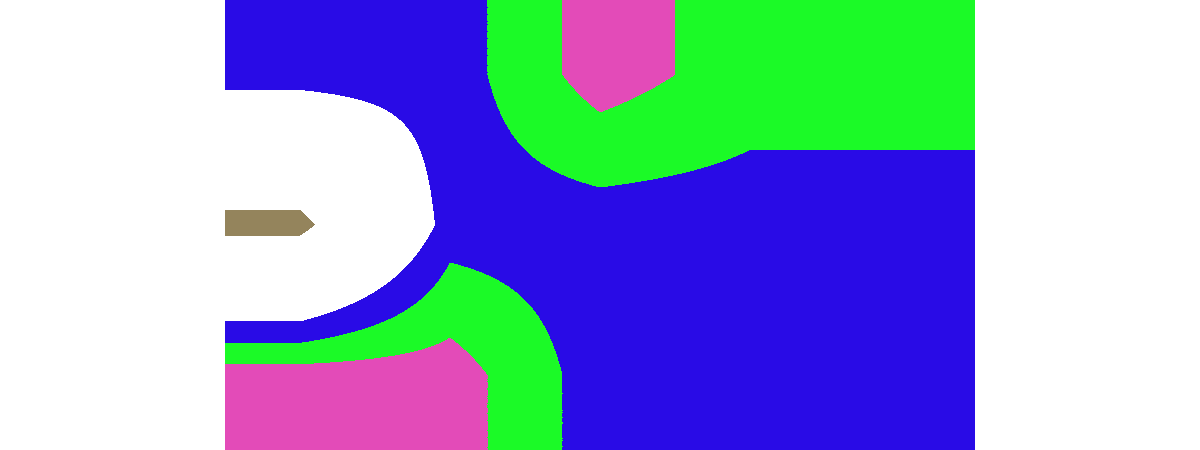

In [11]:
arcgis.env.analysis_extent = aoi
summarize_raster_within_3 = arcgis.raster.analytics.summarize_raster_within(input_zone_layer=degs,
                                                     input_raster_layer_to_summarize=negs,
                                                     zone_field="VALUE",
                                                     ignore_missing_values=True,
                                                     statistic_type="MAJORITY",
                                                     output_name="summarize_raster_within_" + str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                     future=True,
                                                     gis=gis)

summarize_raster_within_3.result().layers[0]

In [12]:
arcgis.env.analysis_extent = None

Summarize Raster Within with Floating point input

Submitted.
Executing...
SummarizeRasterWithin GP Job: j5e249d86ad5742db83b4688e835170f9 finished successfully.


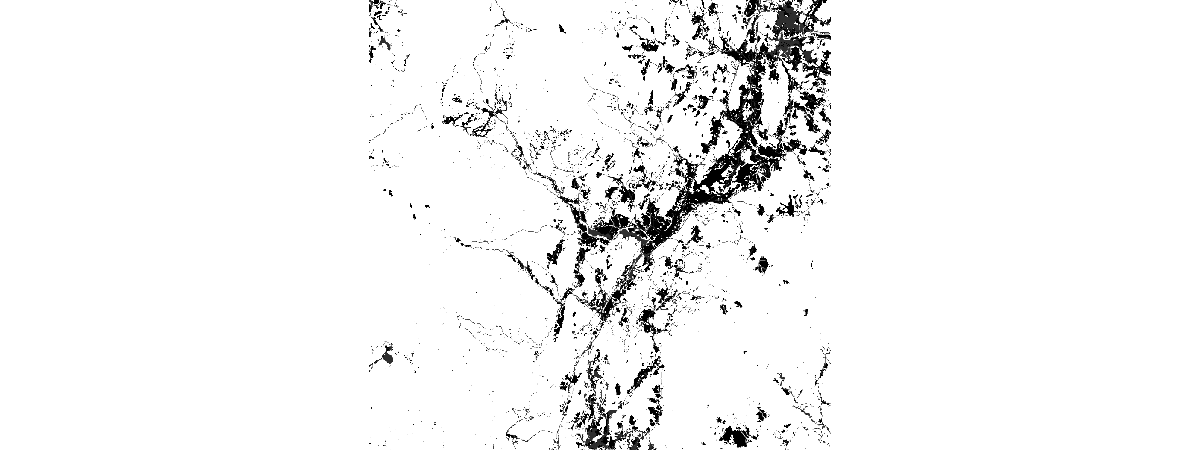

In [13]:
summarize_raster_within_4 = arcgis.raster.analytics.summarize_raster_within(input_zone_layer=multi_srw,
                                                     input_raster_layer_to_summarize=multi_sae,
                                                     zone_field="VALUE",
                                                     ignore_missing_values=True,
                                                     statistic_type="MEAN",
                                                     output_name="summarize_raster_within_" + str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                     gis=gis)

summarize_raster_within_4.layers[0]

<h4> Clean Up

In [14]:
summarize_raster_within_1.delete()

True

In [15]:
summarize_raster_within_2.result().delete()

True

In [16]:
summarize_raster_within_3.result().delete()

True

In [17]:
summarize_raster_within_4.delete()

True